In [1]:
import torch
from coop_dimenet_mod.model import COOP_DimeNet_mod

# Load the model
model = COOP_DimeNet_mod().to('cuda')
model.load_state_dict(torch.load("../weights/checkpoint.pt", weights_only=True))

<All keys matched successfully>

In [2]:
from torch_geometric.data import Batch
from torch_geometric.datasets.qm9 import QM9

# Load a dataset
dataset = QM9(root='dataset', transform=None)
# Get the data containing two molecule graphs: benzene and fluorobenzene
benzene = dataset[208]
fluorobenzene = dataset[4135]

print(f"{benzene.name=}, {fluorobenzene.name=}")
# Create a batch from the two molecule graphs
data = Batch.from_data_list([benzene, fluorobenzene]).to('cuda')

# Define the target bond indices
target_bond_index = [0, 27, 29, 32]

# Predict overlap populations
with torch.no_grad():
    op = model.forward(
        pos=data.pos,
        z=data.z,
        edgelist_forbatch=data.edge_index[:, target_bond_index].T,
        batch=data.batch
    )

benzene.name='gdb_214', fluorobenzene.name='gdb_4208'


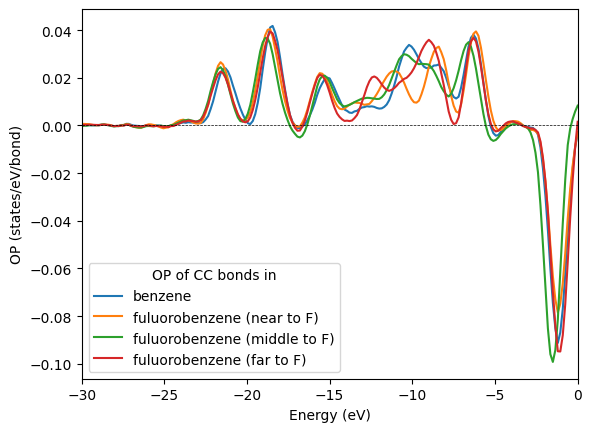

In [3]:
import matplotlib.pyplot as plt

# plot the overlap populations
fig, ax = plt.subplots(1, 1)
energies = torch.linspace(-30, 0., 201).numpy()
for y, label in zip(op,  ["benzene", "fuluorobenzene (near to F)", "fuluorobenzene (middle to F)", "fuluorobenzene (far to F)"]):
    ax.plot(energies, y.cpu().detach().numpy(), label=label)
ax.axhline(0, color='black', linewidth=0.5, linestyle="--")
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('OP (states/eV/bond)')
ax.set_xlim(-30, 0)
ax.legend(title="OP of CC bonds in")
fig.show()